# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Data

In [2]:
df = pd.read_excel("Flight_Fare.xlsx")

In [3]:
 df.shape

(10683, 11)

In [4]:
df.columns.tolist()

['Airline',
 'Date_of_Journey',
 'Source',
 'Destination',
 'Route',
 'Dep_Time',
 'Arrival_Time',
 'Duration',
 'Total_Stops',
 'Additional_Info',
 'Price']

In [5]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


#  Basic Info & Missing Values

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [7]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(220)

In [9]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


#  Drop Nulls & Duplicates

In [10]:
df.dropna(inplace=True)

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.reset_index(drop=True, inplace=True)

In [13]:
df.shape

(10462, 11)

#  EDA

 # Price Distribution

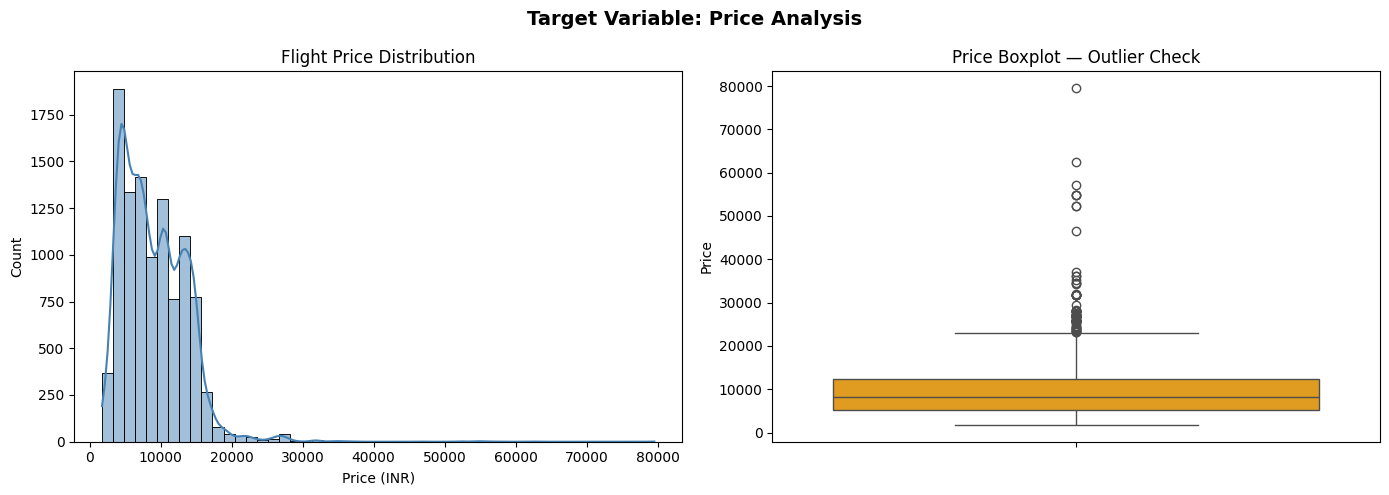

Mean  : ₹9026.79
Median: ₹8266.00
Skew  : 1.86


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Price'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Flight Price Distribution')
axes[0].set_xlabel('Price (INR)')

sns.boxplot(y=df['Price'], ax=axes[1], color='orange')
axes[1].set_title('Price Boxplot — Outlier Check')

plt.suptitle('Target Variable: Price Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Mean  : ₹{df['Price'].mean():.2f}")
print(f"Median: ₹{df['Price'].median():.2f}")
print(f"Skew  : {df['Price'].skew():.2f}")

### Insight

The flight price distribution is right-skewed, indicating that most tickets are priced in the lower to mid range, while only a few are very expensive.
This suggests the presence of outliers and supports the need for outlier handling before model training.

#  Airline vs Price 

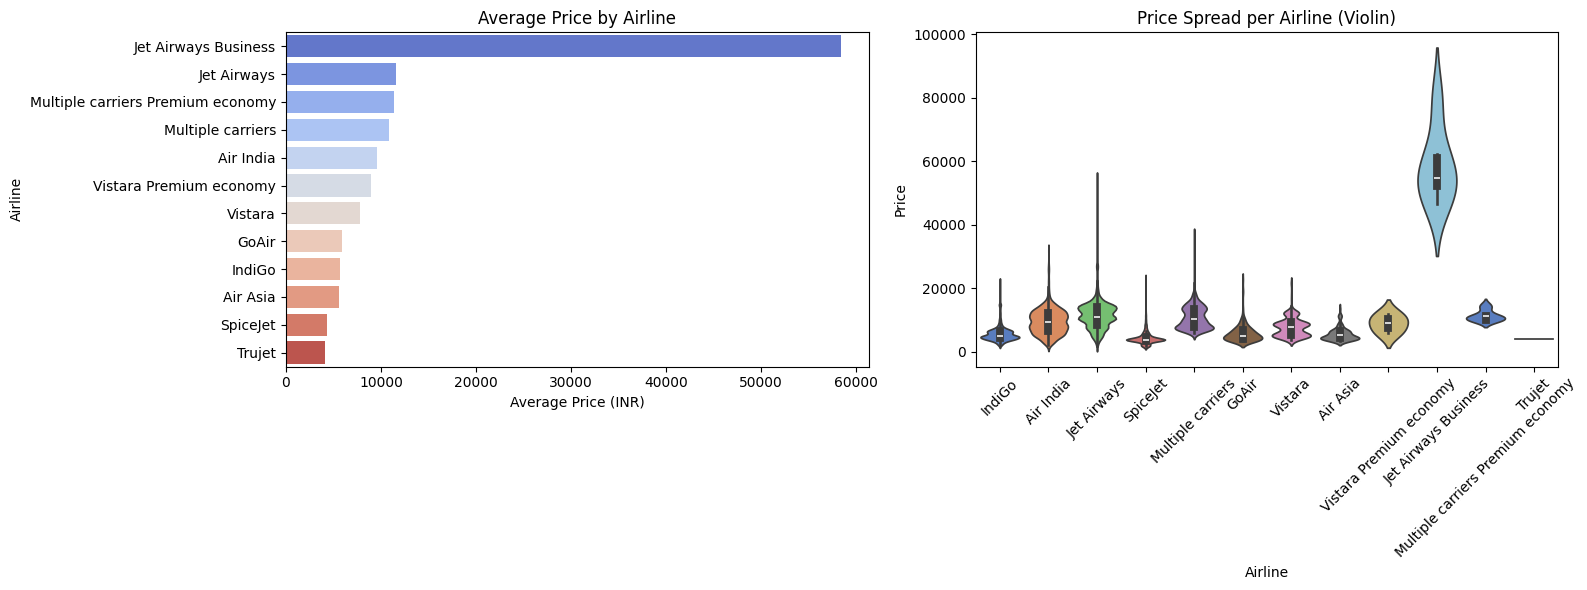

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

airline_avg = df.groupby('Airline')['Price'].mean().sort_values(ascending=False)
sns.barplot(x=airline_avg.values, y=airline_avg.index, palette='coolwarm', ax=axes[0])
axes[0].set_title('Average Price by Airline')
axes[0].set_xlabel('Average Price (INR)')

sns.violinplot(data=df, x='Airline', y='Price', palette='muted', ax=axes[1])
axes[1].set_title('Price Spread per Airline (Violin)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Insight

Different airlines show significant variation in average ticket prices, with premium airlines generally charging higher fares.
Budget carriers tend to offer lower prices, making airline choice an important factor in price prediction.

#  Source & Destination vs Price

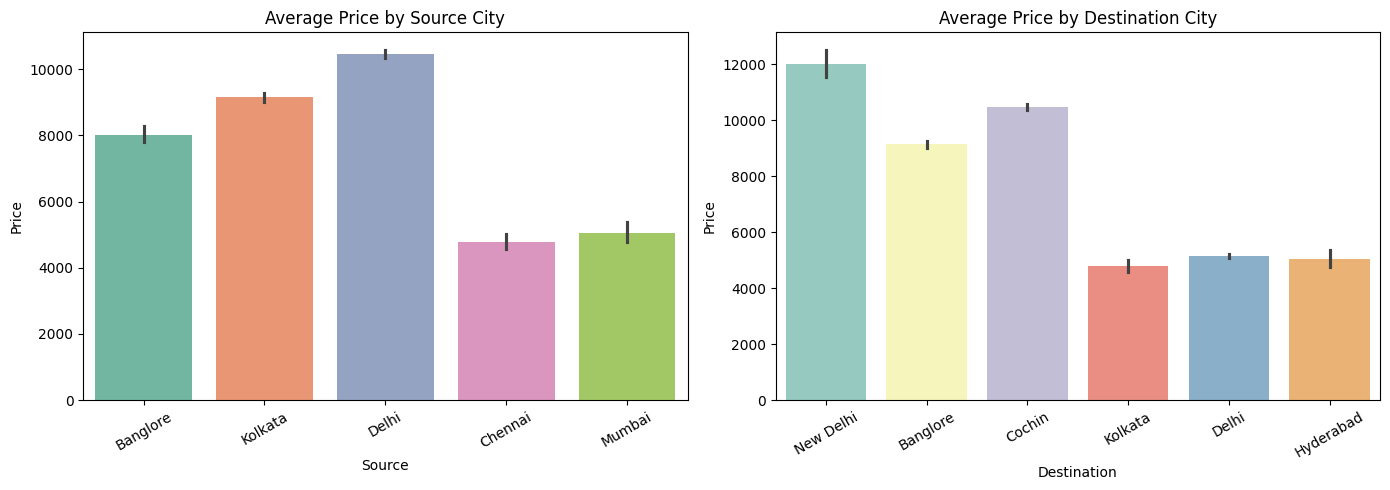

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=df, x='Source', y='Price', palette='Set2', ax=axes[0])
axes[0].set_title('Average Price by Source City')
axes[0].tick_params(axis='x', rotation=30)
sns.barplot(data=df, x='Destination', y='Price', palette='Set3', ax=axes[1])
axes[1].set_title('Average Price by Destination City')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

# Total Stops vs Price

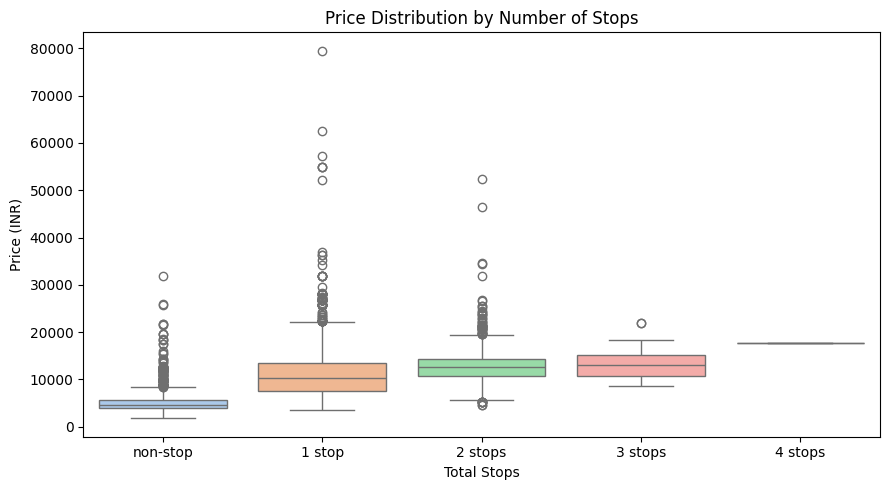

Total_Stops
4 stops     17686.000000
3 stops     13260.674419
2 stops     12761.099393
1 stop      10594.123556
non-stop     5018.506763
Name: Price, dtype: float64


In [17]:
stop_order = ['non-stop', '1 stop', '2 stops', '3 stops', '4 stops']
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='Total_Stops', y='Price', order=stop_order, palette='pastel')
plt.title('Price Distribution by Number of Stops')
plt.xlabel('Total Stops')
plt.ylabel('Price (INR)')
plt.tight_layout()
plt.show()
print(df.groupby('Total_Stops')['Price'].mean().sort_values(ascending=False))

#  Correlation Heatmap

# Insight

Flights with more stops generally have higher ticket prices due to increased travel time and operational complexity.
Non-stop flights may also be expensive because they offer faster and more convenient travel for passengers.

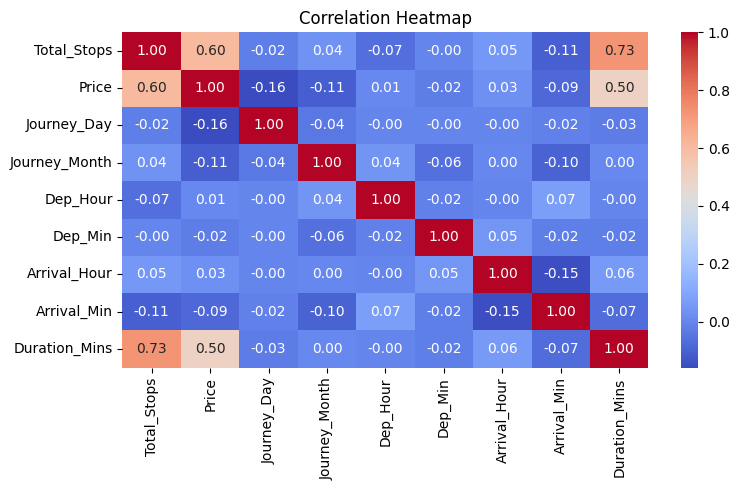

In [38]:
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(8, 5))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# Insight

The heatmap shows that duration, total stops, and airline-related features have stronger relationships with ticket prices.

Highly correlated features help improve model performance and guide effective feature selection.

# Chi-Squared Test

In [19]:
df['Price_Cat'] = pd.cut(df['Price'], bins=3, labels=['Low', 'Medium', 'High'])
cat_cols = ['Airline', 'Source', 'Destination', 'Total_Stops']
print("=== Chi-Squared Test: Feature vs Price Category ===\n")
for col in cat_cols:
    ct = pd.crosstab(df[col], df['Price_Cat'])
    chi2, p, dof, _ = chi2_contingency(ct)
    result = "Significant" if p < 0.05 else "Not Significant"
    print(f"{col:<25} chi2={chi2:>8.2f}  p={p:.4f}  → {result}")

df.drop(columns=['Price_Cat'], inplace=True)

=== Chi-Squared Test: Feature vs Price Category ===

Airline                   chi2= 3156.06  p=0.0000  → Significant
Source                    chi2=   68.87  p=0.0000  → Significant
Destination               chi2=  206.89  p=0.0000  → Significant
Total_Stops               chi2=   17.64  p=0.0241  → Significant


#  Feature Engineering

# Date & Time

In [20]:
df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'], format='%d/%m/%Y')
df['Journey_Day']     = df['Date_of_Journey'].dt.day
df['Journey_Month']   = df['Date_of_Journey'].dt.month
df.drop(columns=['Date_of_Journey'], inplace=True)

df['Dep_Time'] = pd.to_datetime(df['Dep_Time'], format='%H:%M')
df['Dep_Hour'] = df['Dep_Time'].dt.hour
df['Dep_Min']  = df['Dep_Time'].dt.minute
df.drop(columns=['Dep_Time'], inplace=True)

df['Arrival_Time'] = df['Arrival_Time'].str.extract(r'(\d{1,2}:\d{2})')
df['Arrival_Time'] = pd.to_datetime(df['Arrival_Time'], format='%H:%M')
df['Arrival_Hour'] = df['Arrival_Time'].dt.hour
df['Arrival_Min']  = df['Arrival_Time'].dt.minute
df.drop(columns=['Arrival_Time'], inplace=True)

print("Date & Time features extracted ")
df[['Journey_Day','Journey_Month','Dep_Hour','Dep_Min','Arrival_Hour','Arrival_Min']].head()

Date & Time features extracted 


,Journey_Day,Journey_Month,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min
0,24,3,22,20,1,10
1,1,5,5,50,13,15
2,9,6,9,25,4,25
3,12,5,18,5,23,30
4,1,3,16,50,21,35


# Duration

In [21]:
def parse_duration(dur):
    hours, minutes = 0, 0
    for part in str(dur).strip().split():
        if 'h' in part:
            hours = int(part.replace('h', ''))
        elif 'm' in part:
            minutes = int(part.replace('m', ''))
    return hours * 60 + minutes

df['Duration_Mins'] = df['Duration'].apply(parse_duration)
df.drop(columns=['Duration', 'Route', 'Additional_Info'], inplace=True)

print("Duration converted to minutes ")
print(df['Duration_Mins'].describe())

Duration converted to minutes 
count    10462.000000
mean       629.781591
std        500.699045
min          5.000000
25%        170.000000
50%        505.000000
75%        910.000000
max       2860.000000
Name: Duration_Mins, dtype: float64


# Encode Total_Stops

In [22]:
stop_map = {
    'non-stop': 0,
    '1 stop':   1,
    '2 stops':  2,
    '3 stops':  3,
    '4 stops':  4
}
df['Total_Stops'] = df['Total_Stops'].map(stop_map)

print("Total_Stops encoded ")
print(df['Total_Stops'].value_counts())

Total_Stops encoded 
Total_Stops
1    5625
0    3475
2    1318
3      43
4       1
Name: count, dtype: int64


# One-Hot Encode Categorical Columns

In [23]:
df = pd.get_dummies(df, columns=['Airline', 'Source', 'Destination'], drop_first=True)
print("One-Hot Encoding done ")
print("Shape after encoding:", df.shape)

One-Hot Encoding done 
Shape after encoding: (10462, 29)


# Feature Scaling

In [24]:
X = df.drop(columns=['Price'])
y = df['Price']

num_cols = ['Journey_Day', 'Journey_Month', 'Dep_Hour', 'Dep_Min',
            'Arrival_Hour', 'Arrival_Min', 'Duration_Mins', 'Total_Stops']

scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

print("StandardScaler applied ")
X[num_cols].describe().round(2)

StandardScaler applied 


,Journey_Day,Journey_Month,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_Mins,Total_Stops
count,10462.00,10462.00,10462.00,10462.00,10462.00,10462.00,10462.00,10462.00
mean,-0.00,0.00,0.00,0.00,-0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.47,-1.46,-2.18,-1.30,-1.95,-1.49,-1.25,-1.21
25%,-0.88,-1.46,-0.78,-1.03,-0.79,-0.89,-0.92,-1.21
50%,-0.17,0.26,-0.26,0.03,0.09,0.02,-0.25,0.30
75%,0.89,1.12,0.96,0.83,0.82,0.62,0.56,0.30
max,1.60,1.12,1.84,1.63,1.40,1.83,4.45,4.84


# Train-Test Split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test  size:", X_test.shape)

Train size: (8369, 28)
Test  size: (2093, 28)


# Models

In [26]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree':     DecisionTreeRegressor(random_state=42),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost':           XGBRegressor(random_state=42, verbosity=0)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    results.append({'Model': name, 'MAE': round(mae,2), 'RMSE': round(rmse,2), 'R2': round(r2,4)})
    print(f"{name:<25} MAE: {mae:>8.2f}  RMSE: {rmse:>8.2f}  R²: {r2:.4f}")

results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
results_df

Linear Regression         MAE:  1998.64  RMSE:  2945.80  R²: 0.5838
Decision Tree             MAE:  1382.29  RMSE:  2438.41  R²: 0.7148
Random Forest             MAE:  1172.39  RMSE:  1971.83  R²: 0.8135
Gradient Boosting         MAE:  1536.82  RMSE:  2267.96  R²: 0.7533
XGBoost                   MAE:  1132.73  RMSE:  1841.55  R²: 0.8373


,Model,MAE,RMSE,R2
0,XGBoost,1132.73,1841.55,0.8373
1,Random Forest,1172.39,1971.83,0.8135
2,Gradient Boosting,1536.82,2267.96,0.7533
3,Decision Tree,1382.29,2438.41,0.7148
4,Linear Regression,1998.64,2945.80,0.5838


# Hyperparameter Tuning

In [27]:
param_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2']
}

rf = RandomForestRegressor(random_state=42)

rs = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rs.fit(X_train, y_train)

print("\nBest Parameters:", rs.best_params_)
print("Best CV R² Score:", round(rs.best_score_, 4))

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30}
Best CV R² Score: 0.8142


# Evaluate Tuned Model

In [28]:
best_model  = rs.best_estimator_
tuned_preds = best_model.predict(X_test)

mae  = mean_absolute_error(y_test, tuned_preds)
rmse = np.sqrt(mean_squared_error(y_test, tuned_preds))
r2   = r2_score(y_test, tuned_preds)

print("=== Tuned Random Forest — Final Performance ===")
print(f"MAE  : ₹{mae:.2f}")
print(f"RMSE : ₹{rmse:.2f}")
print(f"R²   : {r2:.4f}")

=== Tuned Random Forest — Final Performance ===
MAE  : ₹1231.25
RMSE : ₹1979.44
R²   : 0.8121


In [29]:
mape = np.mean(np.abs((y_test - tuned_preds) / y_test)) * 100

print("=" * 45)
print("     MODEL EVALUATION REPORT")
print("     Tuned Random Forest Regressor")
print("=" * 45)
print(f"  MAE  : ₹{mae:.2f}")
print(f"  RMSE : ₹{rmse:.2f}")
print(f"  MAPE : {mape:.2f}%")
print(f"  R²   : {r2:.4f}")
print("=" * 45)
print(f"  Model explains {r2*100:.2f}% of price variance.")
print(f"  Avg prediction error: ₹{mae:.0f}")
print("=" * 45)

     MODEL EVALUATION REPORT
     Tuned Random Forest Regressor
  MAE  : ₹1231.25
  RMSE : ₹1979.44
  MAPE : 14.26%
  R²   : 0.8121
  Model explains 81.21% of price variance.
  Avg prediction error: ₹1231


  CLASSIFICATION REPORT (Price Category)
              precision    recall  f1-score   support

      Budget       0.93      0.83      0.88       491
   Mid-Range       0.81      0.78      0.80       783
     Premium       0.84      0.93      0.89       819

    accuracy                           0.85      2093
   macro avg       0.86      0.85      0.85      2093
weighted avg       0.85      0.85      0.85      2093



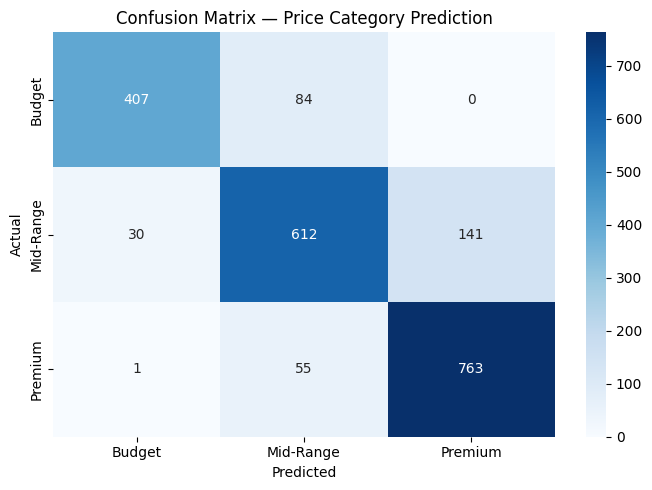

In [30]:
from sklearn.metrics import classification_report, confusion_matrix

# Bin actual and predicted prices into 3 classes
bins   = [0, 5000, 10000, 100000]
labels = ['Budget', 'Mid-Range', 'Premium']

y_test_class  = pd.cut(y_test,       bins=bins, labels=labels)
y_pred_class  = pd.cut(tuned_preds,  bins=bins, labels=labels)

print("=" * 50)
print("  CLASSIFICATION REPORT (Price Category)")
print("=" * 50)
print(classification_report(y_test_class, y_pred_class, target_names=labels))

# Confusion Matrix
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test_class, y_pred_class, labels=labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix — Price Category Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Actual vs Predicted 

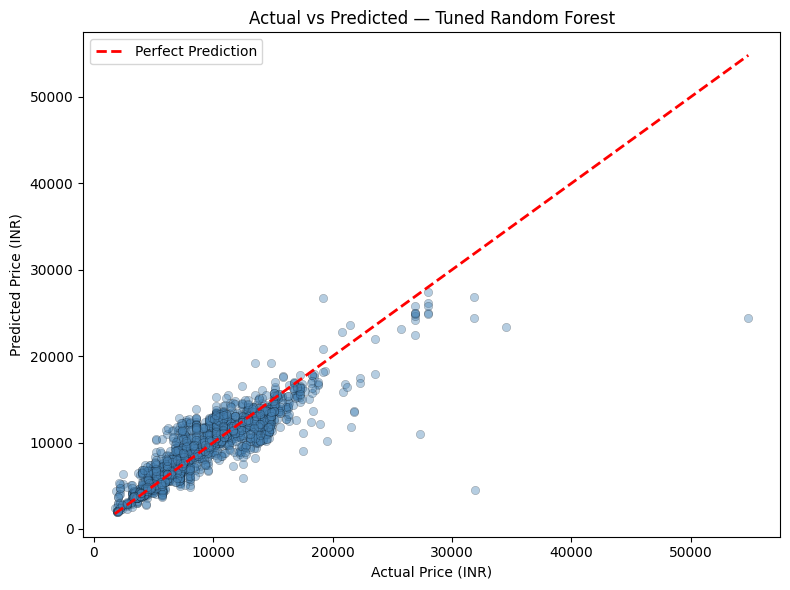

Observation: Points close to red line = accurate predictions.


In [31]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, tuned_preds, alpha=0.4, color='steelblue', edgecolors='k', linewidths=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Price (INR)')
plt.ylabel('Predicted Price (INR)')
plt.title('Actual vs Predicted — Tuned Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

print("Observation: Points close to red line = accurate predictions.")

#  Model Comparison

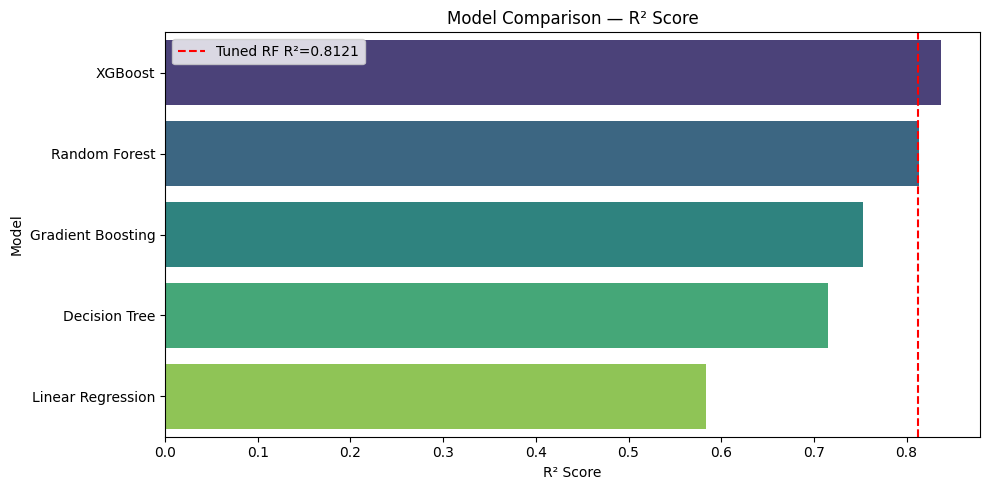

In [32]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x='R2', y='Model', palette='viridis')
plt.axvline(x=r2, color='red', linestyle='--', linewidth=1.5, label=f'Tuned RF R²={r2:.4f}')
plt.title('Model Comparison — R² Score')
plt.xlabel('R² Score')
plt.legend()
plt.tight_layout()
plt.show()

# Feature Importance

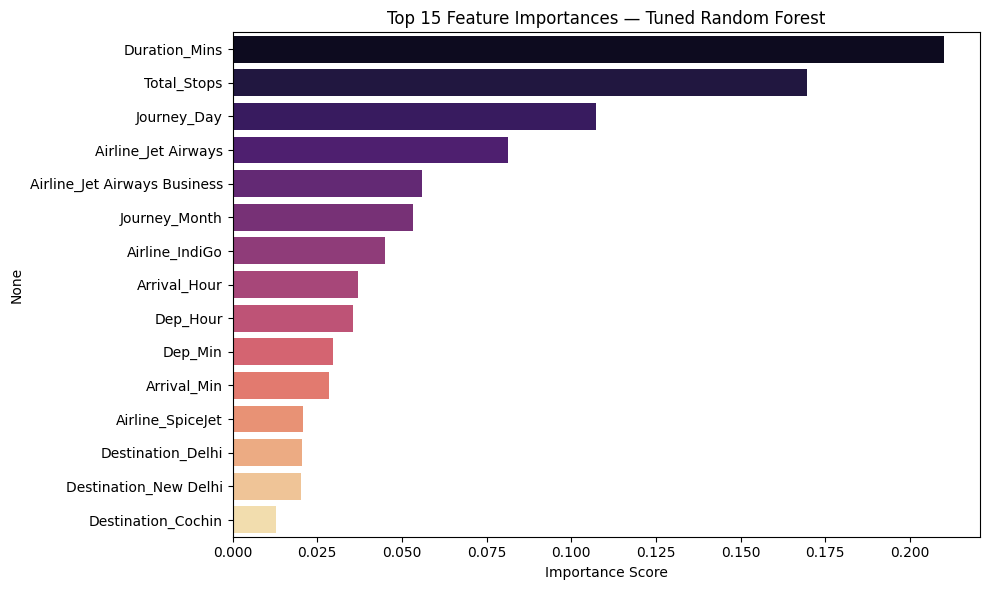

In [33]:
feat_imp = pd.Series(best_model.feature_importances_, index=X.columns)
top15    = feat_imp.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top15.values, y=top15.index, palette='magma')
plt.title('Top 15 Feature Importances — Tuned Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# Model Comparison Report

In [34]:
print("""
=== MODEL COMPARISON REPORT ===

Best Model : Tuned Random Forest Regressor

Trade-off Summary:
----------------------------------------------------------
Linear Regression  → Fast and interpretable. Struggles with
                     non-linear price patterns. Lowest R².

Decision Tree      → Easy to explain. Prone to overfitting
                     on unseen routes.

Random Forest      → Best accuracy + generalization.
                     Handles non-linearity well.  ✅ WINNER

Gradient Boosting  → Strong performance but slower to train
                     compared to Random Forest.

XGBoost            → Competitive but needs deeper tuning
                     for this specific dataset.
----------------------------------------------------------
Why Random Forest wins:
  - Handles complex interaction between stops, airline,
    duration, and price without assumptions.
  - Robust to outliers in price distribution.
  - After RandomizedSearchCV tuning, generalizes best
    on unseen test data.
""")


=== MODEL COMPARISON REPORT ===

Best Model : Tuned Random Forest Regressor

Trade-off Summary:
----------------------------------------------------------
Linear Regression  → Fast and interpretable. Struggles with
                     non-linear price patterns. Lowest R².

Decision Tree      → Easy to explain. Prone to overfitting
                     on unseen routes.

Random Forest      → Best accuracy + generalization.
                     Handles non-linearity well.  ✅ WINNER

Gradient Boosting  → Strong performance but slower to train
                     compared to Random Forest.

XGBoost            → Competitive but needs deeper tuning
                     for this specific dataset.
----------------------------------------------------------
Why Random Forest wins:
  - Handles complex interaction between stops, airline,
    duration, and price without assumptions.
  - Robust to outliers in price distribution.
  - After RandomizedSearchCV tuning, generalizes best
    on unseen 

# Challenges Faced

In [35]:
print("""
=== CHALLENGES & SOLUTIONS ===

1. Duration in mixed string format (e.g. '2h 50m', '19h')
   → Custom parse_duration() to convert to total minutes.

2. Arrival_Time had date suffixes in some rows (e.g. '01:10 22 Mar')
   → Used regex to extract only the HH:MM part before parsing.

3. Total_Stops contained NaN values
   → Dropped with dropna() at the cleaning stage.

4. High cardinality after One-Hot Encoding
   → Used drop_first=True to reduce multicollinearity.

5. Outliers in Price (very high business-class fares)
   → Retained after EDA confirmed they are valid data points.
     Boxplots used for visual confirmation.

6. Feature scaling was missing in baseline
   → StandardScaler applied to all numerical columns,
     especially important for Linear Regression accuracy.
""")


=== CHALLENGES & SOLUTIONS ===

1. Duration in mixed string format (e.g. '2h 50m', '19h')
   → Custom parse_duration() to convert to total minutes.

2. Arrival_Time had date suffixes in some rows (e.g. '01:10 22 Mar')
   → Used regex to extract only the HH:MM part before parsing.

3. Total_Stops contained NaN values
   → Dropped with dropna() at the cleaning stage.

4. High cardinality after One-Hot Encoding
   → Used drop_first=True to reduce multicollinearity.

5. Outliers in Price (very high business-class fares)
   → Retained after EDA confirmed they are valid data points.
     Boxplots used for visual confirmation.

6. Feature scaling was missing in baseline
   → StandardScaler applied to all numerical columns,
     especially important for Linear Regression accuracy.



# Conclusion

In [36]:
print("""
=== CONCLUSION ===

This project built a Flight Price Prediction system using
machine learning on 10,000+ real flight records.

Key findings from Feature Importance:
  - Duration_Mins and Total_Stops are the strongest predictors.
  - Airline type significantly impacts pricing.
  - Journey month and departure hour also influence price.

Limitations:
  - Model may underperform for airlines not seen in training.
  - External factors like fuel prices, demand spikes, and
    festivals are not captured in this dataset.

Next Steps:
  - Try LightGBM or CatBoost for further accuracy gains.
  - Add seasonal demand and holiday features.
  - Deploy as a Streamlit web app for real-time predictions.
""")


=== CONCLUSION ===

This project built a Flight Price Prediction system using
machine learning on 10,000+ real flight records.

Key findings from Feature Importance:
  - Duration_Mins and Total_Stops are the strongest predictors.
  - Airline type significantly impacts pricing.
  - Journey month and departure hour also influence price.

Limitations:
  - Model may underperform for airlines not seen in training.
  - External factors like fuel prices, demand spikes, and
    festivals are not captured in this dataset.

Next Steps:
  - Try LightGBM or CatBoost for further accuracy gains.
  - Add seasonal demand and holiday features.
  - Deploy as a Streamlit web app for real-time predictions.

